In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn

In [46]:
df = pd.read_csv('avocado_clean.csv')

In [47]:
df['Date'] = df['Date'].astype('datetime64[ns]')

In [48]:
daily_avg_df = df.groupby('Date').mean(numeric_only=True).reset_index()
display(daily_avg_df.head())

,Date,AveragePrice,Total Volume,4046,4225,Total Bags,Small Bags
0,2015-01-04,1.458082,56877.936164,21037.432055,20411.174110,12613.493288,10251.013973
1,2015-01-11,1.507867,57483.579333,20790.800667,20599.225733,13010.113733,10264.573467
2,2015-01-18,1.522703,52323.519189,17411.634595,20101.925946,12956.363919,10033.555946
3,2015-01-25,1.547361,47756.546667,16608.294167,17314.094722,12127.031250,9581.129722
4,2015-02-01,1.444687,48856.947656,16159.000469,19576.109219,9432.474531,6933.344063


In [49]:
all_columns_daily = daily_avg_df.columns.tolist()
columns_to_plot_daily = [col for col in all_columns_daily if col != 'Date']
print(columns_to_plot_daily)

['AveragePrice', 'Total Volume', '4046', '4225', 'Total Bags', 'Small Bags']


# Regresión lineal simple (utilizando como variable dependiente el tiempo)

Se hara una regresión lineal para todas las anteriores variables mostradas

In [50]:
daily_avg_df['Date_numeric'] = daily_avg_df['Date'].astype('int64') // 10**9

In [51]:
all_columns_daily = daily_avg_df.columns.tolist()
dependent_variables = [col for col in all_columns_daily if col not in ['Date', 'Date_numeric']]
print(dependent_variables)

['AveragePrice', 'Total Volume', '4046', '4225', 'Total Bags', 'Small Bags']



Performing linear regression for: AveragePrice
                            OLS Regression Results                            
Dep. Variable:           AveragePrice   R-squared:                       0.117
Model:                            OLS   Adj. R-squared:                  0.112
Method:                 Least Squares   F-statistic:                     22.19
Date:                Fri, 21 Nov 2025   Prob (F-statistic):           5.17e-06
Time:                        22:16:08   Log-Likelihood:                 123.56
No. Observations:                 169   AIC:                            -243.1
Df Residuals:                     167   BIC:                            -236.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------


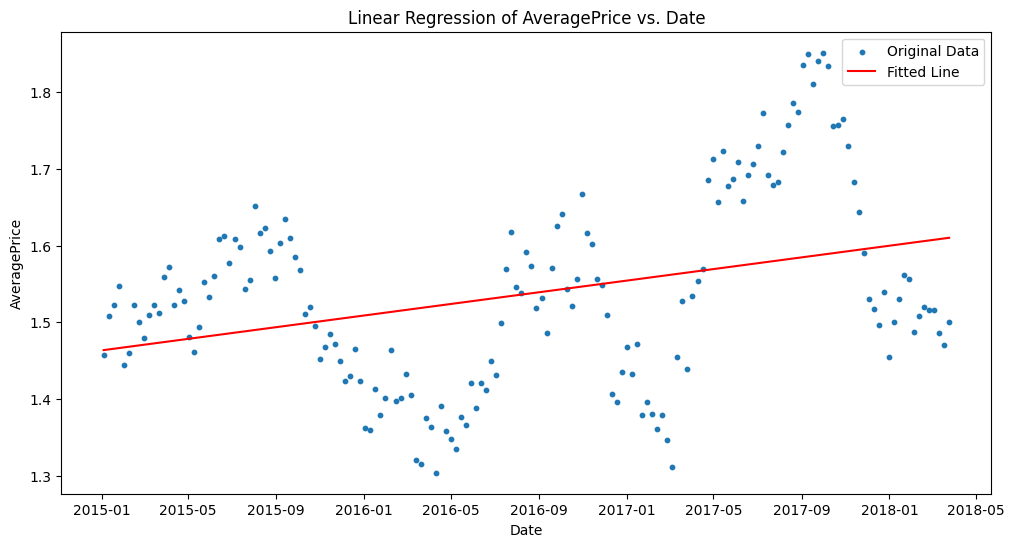


Performing linear regression for: Total Volume
                            OLS Regression Results                            
Dep. Variable:           Total Volume   R-squared:                       0.066
Model:                            OLS   Adj. R-squared:                  0.060
Method:                 Least Squares   F-statistic:                     11.75
Date:                Fri, 21 Nov 2025   Prob (F-statistic):           0.000766
Time:                        22:16:08   Log-Likelihood:                -1709.6
No. Observations:                 169   AIC:                             3423.
Df Residuals:                     167   BIC:                             3429.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------


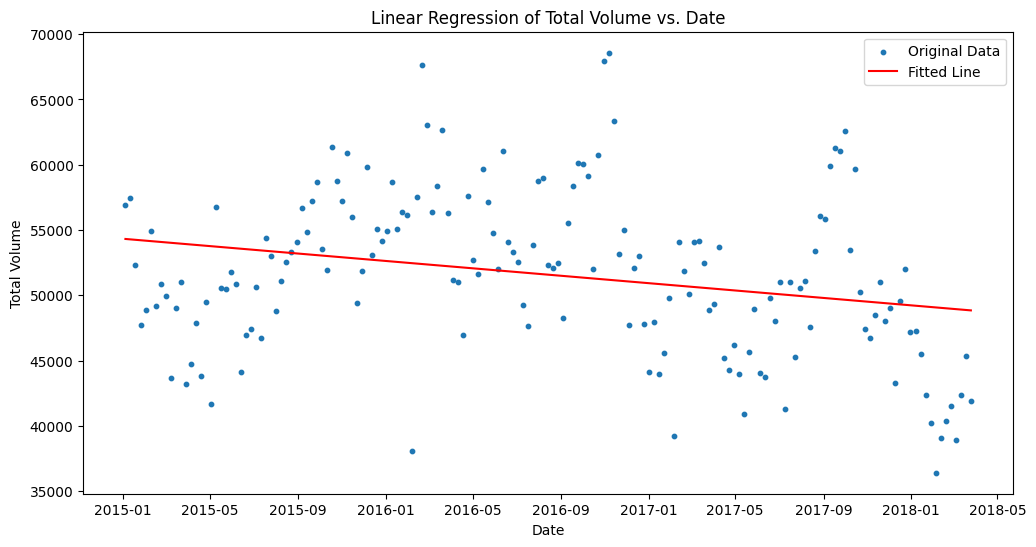


Performing linear regression for: 4046
                            OLS Regression Results                            
Dep. Variable:                   4046   R-squared:                       0.486
Model:                            OLS   Adj. R-squared:                  0.483
Method:                 Least Squares   F-statistic:                     158.0
Date:                Fri, 21 Nov 2025   Prob (F-statistic):           6.31e-26
Time:                        22:16:08   Log-Likelihood:                -1574.2
No. Observations:                 169   AIC:                             3152.
Df Residuals:                     167   BIC:                             3159.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const   

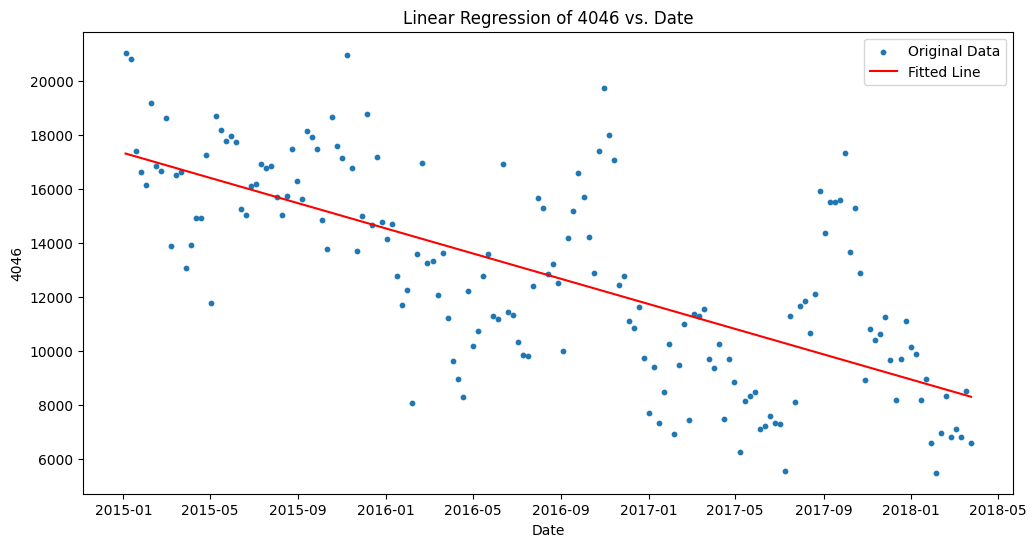


Performing linear regression for: 4225
                            OLS Regression Results                            
Dep. Variable:                   4225   R-squared:                       0.450
Model:                            OLS   Adj. R-squared:                  0.447
Method:                 Least Squares   F-statistic:                     136.7
Date:                Fri, 21 Nov 2025   Prob (F-statistic):           1.88e-23
Time:                        22:16:08   Log-Likelihood:                -1551.6
No. Observations:                 169   AIC:                             3107.
Df Residuals:                     167   BIC:                             3113.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const   

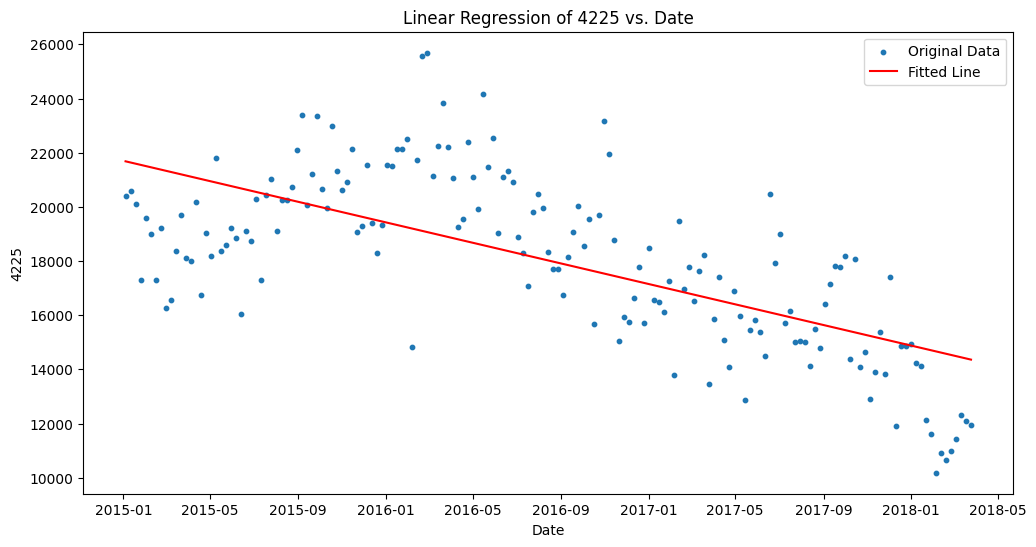


Performing linear regression for: Total Bags
                            OLS Regression Results                            
Dep. Variable:             Total Bags   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.680
Method:                 Least Squares   F-statistic:                     358.4
Date:                Fri, 21 Nov 2025   Prob (F-statistic):           2.02e-43
Time:                        22:16:09   Log-Likelihood:                -1570.3
No. Observations:                 169   AIC:                             3145.
Df Residuals:                     167   BIC:                             3151.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
co

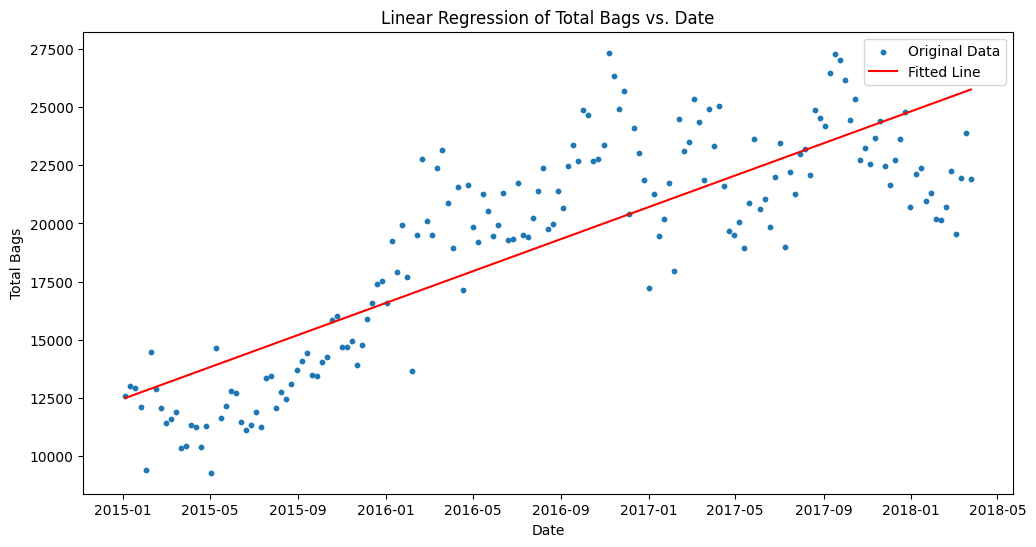


Performing linear regression for: Small Bags
                            OLS Regression Results                            
Dep. Variable:             Small Bags   R-squared:                       0.641
Model:                            OLS   Adj. R-squared:                  0.639
Method:                 Least Squares   F-statistic:                     298.0
Date:                Fri, 21 Nov 2025   Prob (F-statistic):           5.60e-39
Time:                        22:16:09   Log-Likelihood:                -1517.5
No. Observations:                 169   AIC:                             3039.
Df Residuals:                     167   BIC:                             3045.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
co

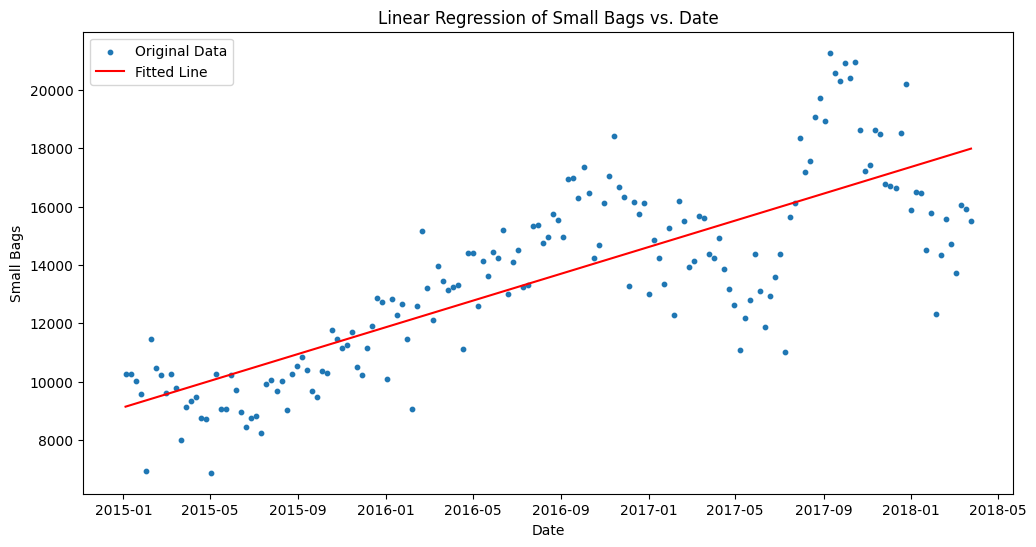

In [52]:
import statsmodels.api as sm

dependent_variables = ['AveragePrice', 'Total Volume', '4046', '4225', 'Total Bags', 'Small Bags']

for column_name in dependent_variables:
    print(f"\nPerforming linear regression for: {column_name}")

    # Define independent and dependent variables
    X = daily_avg_df['Date_numeric']
    y = daily_avg_df[column_name]

    # Add a constant to the independent variable
    X = sm.add_constant(X)

    # Create and fit the OLS model
    model = sm.OLS(y, X)
    results = model.fit()

    # Print the regression results
    print(results.summary())

    # Plotting the results
    plt.figure(figsize=(12, 6))
    plt.scatter(daily_avg_df['Date'], y, label='Original Data', s=10)
    plt.plot(daily_avg_df['Date'], results.predict(X), color='red', label='Fitted Line')
    plt.title(f'Linear Regression of {column_name} vs. Date')
    plt.xlabel('Date')
    plt.ylabel(column_name)
    plt.legend()
    plt.show()

## Top 10 precios más altos y bajos de precio promedio del aguacate orgánico

In [53]:

lowest_10_regions = average_price_organic_by_region.tail(10)
print("10 Regions with Lowest Average Organic Avocado Price:")
display(lowest_10_regions)


greatest_10_regions = average_price_organic_by_region.head(10)
print("\n10 Regions with Greatest Average Organic Avocado Price:")
display(greatest_10_regions)

10 Regions with Lowest Average Organic Avocado Price:


,region,Average Price Organic
38,RichmondNorfolk,1.462840
10,Columbus,1.439290
13,Detroit,1.428225
26,Nashville,1.411302
9,CincinnatiDayton,1.402899
39,Roanoke,1.399822
12,Denver,1.370659
45,SouthCentral,1.345795
11,DallasFtWorth,1.324734
18,Houston,1.270769



10 Regions with Greatest Average Organic Avocado Price:


,region,Average Price Organic
17,HartfordSpringfield,2.192597
28,NewYork,2.058970
42,SanFrancisco,1.970000
40,Sacramento,1.938696
7,Charlotte,1.889811
32,Philadelphia,1.867929
29,Northeast,1.860494
20,Jacksonville,1.807818
37,RaleighGreensboro,1.803935
31,Orlando,1.780181
